# Quality control for registered PET scans

In [ ]:
import pandas as pd
import numpy as np
import nibabel as nib
import scipy
import statsmodels
import math


import matplotlib.pyplot as plt
import seaborn as sns

import ants

import sys
import os, fnmatch


In [8]:
#meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/metafile_completing/metafile_ADDLpipeline_abeta_mri_02_06_2024.csv',header=[0], index_col=[0])
meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])

meta.reset_index(drop=True, inplace = True)
meta = meta.iloc[:,1:]

In [9]:
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')

In [10]:
meta.columns

Index(['Project', 'Phase', 'Sex', 'Weight', 'Research.Group', 'VISCODE',
       'Study.Date', 'Age', 'Modality', 'Description', 'Imaging.Protocol',
       'Image.Data.ID', 'modality_subtype', 'PATH', 'MRI_subID',
       'MRI_Modality', 'MRI_Research.Group', 'MRI_Age', 'MRI_VISCODE',
       'MRI_studydate', 'MRI_Description', 'MRI_Imaging.protocol', 'MRI_Type',
       'MRI_ID', 'MRI_PATH', 'PET_PATH_normalised', 'MRI_PATH_registered',
       'pet_min', 'pet_max', 'pet_90q', 'pet_95q', 'pet_99q', 'pet_999q',
       'mri_min', 'mri_max', 'mri_90q', 'mri_95q', 'mri_99q', 'mri_999q'],
      dtype='object')

In [12]:
# add path to registered pet and mri scans
for i in range(0,np.shape(meta)[0]):
    name = meta['Image.Data.ID'][i]+'_registered.nii'
    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/'), name)
    if len(filename)> 0:
        meta.loc[i,'PATH_registered'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/' + filename[0]
    
    name_mri = meta['MRI_ID'][i]+'_registered.nii'
    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_mri/'), name_mri)
    if len(filename)> 0:
        meta.loc[i,'MRI_PATH_registered'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_mri/' + filename[0]
         
    #print(i)

In [14]:
meta2 = meta[meta['PATH_registered'].notna()] #!!
meta2.reset_index(drop=True, inplace = True)

In [15]:
meta2

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,Description,...,MRI_Research.Group,MRI_Age,MRI_VISCODE,MRI_studydate,MRI_Description,MRI_Imaging.protocol,MRI_Type,MRI_ID,MRI_PATH,PATH_registered
0,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,1/01/2016,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),...,LEARN amyloidNE,84.0,SCV4,1/01/2016,T1; GradWarp; DeFaced <- Sagittal 3D Accelerat...,NaN,Processed,I1384728,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
1,ADNI,ADNI 2,M,84.9,LMCI,v21,9/30/2013,69.7,PET,"AV45 Co-registered, Averaged <- PET Brain AV_4...",...,LMCI,69.7,v21,9/30/2013,MT1; GradWarp; N3m <- MPRAGE,SIEMENS,Processed,I398283,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
2,ADNI,ADNI 2,M,75.7,CN,v21,1/22/2014,79.2,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",...,CN,79.2,v21,1/21/2014,MT1; GradWarp; N3m <- MPRAGE,SIEMENS,Processed,I416035,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
3,A4,NaN,M,71.4,amyloidE,SCV2,1/01/2016,82.5,PET,Florbetapir <- PET Scan,...,amyloidE,82.6,SCV4,1/01/2016,T1; DeFaced <- Sagittal 3D Accelerated MPRAGE,NaN,Processed,I1364073,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
4,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2016,71.8,PET,Florbetapir <- PET Scan,...,LEARN amyloidNE,71.0,SCV4,1/01/2016,T1; DeFaced <- Sagittal 3D Accelerated MPRAGE,NaN,Processed,I1384417,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3635,ADNI,ADNI 2,F,76.7,CN,v31,1/07/2015,78.9,PET,"AV45 Co-registered, Averaged <- AV45_Dyn_4x5mi...",...,CN,78.8,v31,12/15/2014,MT1; GradWarp; N3m <- MPRAGE,SIEMENS,Processed,I468856,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
3636,ADNI,ADNI GO,M,65.3,CN,m48,12/15/2010,89.3,PET,"AV45 Co-registered, Averaged <- 20 min 3D AV45...",...,CN,89.2,m48,10/13/2010,MT1; GradWarp; N3m <- MP-RAGE REPEAT,GE MEDICAL SYSTEMS,Processed,I322397,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
3637,ADNI,ADNI 2,M,72.1,AD,v21,9/20/2013,81.5,PET,"AV45 Co-registered, Averaged <- Adni AV45 4 X ...",...,AD,81.5,v21,9/16/2013,MT1; N3m <- MPRAGE,Philips Medical Systems,Processed,I391062,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
3638,ADNI,ADNI 2,M,57.5,CN,v31,9/17/2014,79.1,PET,"AV45 Co-registered, Averaged <- ADNIGO - AV45 ...",...,CN,79.1,v31,9/04/2014,MT1; GradWarp; N3m <- MPRAGE,SIEMENS,Processed,I451346,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...


In [25]:
'''meta2['MI'] = np.nan
meta2['correlation'] = np.nan
meta2['MSE'] = np.nan
#for i in range(150,152):
for i in range(meta2.shape[0]):
    pet = ants.image_read(meta2['PATH_registered'][i])
    if 0 in pet.spacing:
        print(f"Skipping image {i}, invalid spacing: {pet.spacing}")
        continue
    try:
        meta2['MI'][i] = ants.image_mutual_information(mni_t1, pet)
        meta2['correlation'][i] = ants.image_similarity(mni_t1, pet, metric_type="Correlation")
        meta2['MSE'][i] = ants.image_similarity(mni_t1, pet, metric_type="MeanSquares")
    except RuntimeError as e:
        print(f"Skipping {i}: {e}")
        

    print(i)'''
    

150
Skipping 151: /project/itksource/Modules/Registration/Metricsv4/include/itkMattesMutualInformationImageToImageMetricv4.hxx:307:
ITK ERROR: MattesMutualInformationImageToImageMetricv4(0x555a3297b3c0): All samples map outside moving image buffer. The images do not sufficiently overlap. They need to be initialized to have more overlap before this metric will work. For instance, you can align the image centers by translation.

151


In [ ]:
import ants
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

# Assuming mni_t1 is already loaded
# mni_t1 = ants.image_read('/path/to/mni_t1.nii.gz')

'''def compute_metrics(i):
    print(f"Processing index: {i}")
    
    try:
        # Read PET and MRI images
        pet = ants.image_read(meta2.loc[i, 'PATH_registered'])
        mri = ants.image_read(meta2.loc[i, 'MRI_PATH'])

        # Validate spacing
        if 0 in pet.spacing:
            return i, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, f"Invalid PET spacing: {pet.spacing}"
        if 0 in mri.spacing:
            return i, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, f"Invalid MRI spacing: {mri.spacing}"

        # Compute PET-to-template metrics
        pet_mi = ants.image_mutual_information(mni_t1, pet)
        pet_corr = ants.image_similarity(mni_t1, pet, metric_type="Correlation")
        pet_mse = ants.image_similarity(mni_t1, pet, metric_type="MeanSquares")

        # Compute MRI-to-template metrics
        mri_mi = ants.image_mutual_information(mni_t1, mri)
        mri_corr = ants.image_similarity(mni_t1, mri, metric_type="Correlation")
        mri_mse = ants.image_similarity(mni_t1, mri, metric_type="MeanSquares")

        return i, pet_mi, pet_corr, pet_mse, mri_mi, mri_corr, mri_mse, None

    except Exception as e:
        # Catch and return error message
        return i, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, f"{type(e).__name__}: {str(e)}"
'''

def compute_metrics(i):
    print(f"Processing index: {i}")
    
    # Initialize default return values
    pet_mi = pet_corr = pet_mse = np.nan
    mri_mi = mri_corr = mri_mse = np.nan
    error_messages = []

    try:
        pet = ants.image_read(meta2.loc[i, 'PATH_registered'])
        if 0 in pet.spacing:
            error_messages.append(f"Invalid PET spacing: {pet.spacing}")
        else:
            pet_mi = ants.image_mutual_information(mni_t1, pet)
            pet_corr = ants.image_similarity(mni_t1, pet, metric_type="Correlation")
            pet_mse = ants.image_similarity(mni_t1, pet, metric_type="MeanSquares")
    except Exception as e:
        error_messages.append(f"PET error: {type(e).__name__}: {str(e)}")

    try:
        mri = ants.image_read(meta2.loc[i, 'MRI_PATH_registered'])
        if 0 in mri.spacing:
            error_messages.append(f"Invalid MRI spacing: {mri.spacing}")
        else:
            mri_mi = ants.image_mutual_information(mni_t1, mri)
            mri_corr = ants.image_similarity(mni_t1, mri, metric_type="Correlation")
            mri_mse = ants.image_similarity(mni_t1, mri, metric_type="MeanSquares")
    except Exception as e:
        error_messages.append(f"MRI error: {type(e).__name__}: {str(e)}")

    # Join error messages if any
    error_msg = "; ".join(error_messages) if error_messages else None

    return i, pet_mi, pet_corr, pet_mse, mri_mi, mri_corr, mri_mse, error_msg


# Initialize columns
meta2['pet_MI'] = np.nan
meta2['pet_correlation'] = np.nan
meta2['pet_MSE'] = np.nan

meta2['mri_MI'] = np.nan
meta2['mri_correlation'] = np.nan
meta2['mri_MSE'] = np.nan
# Run in parallel
with ProcessPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(compute_metrics, range(meta2.shape[0])))

# Fill results into the DataFrame
for i, pet_mi, pet_corr, pet_mse, mri_mi, mri_corr, mri_mse, error in results:
    if error:
        print(f"Skipping {i}: {error}")
    else:
        meta2.at[i, 'pet_MI'] = pet_mi
        meta2.at[i, 'pet_correlation'] = pet_corr
        meta2.at[i, 'pet_MSE'] = pet_mse
        
        meta2.at[i, 'mri_MI'] = mri_mi
        meta2.at[i, 'mri_correlation'] = mri_corr
        meta2.at[i, 'mri_MSE'] = mri_mse
        
print('ready')


In [29]:
pet = ants.image_read(meta2['PATH_registered'][150])

(-0.5, 217.5, 181.5, -0.5)

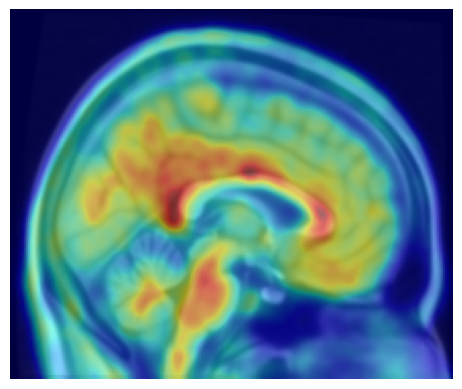

In [30]:
plt.imshow(np.rot90(mni_t1[90, :, :].copy()), cmap = 'gray')
plt.imshow(np.rot90(pet[90, :, :].copy()), cmap = 'jet',alpha = 0.5) 
plt.axis('off')

In [31]:
meta2.shape

(3640, 29)

In [12]:
#meta2.to_csv('metafile_ADDLpipeline_abeta_mri_02_06_2024_regQC.csv', index=False)
meta2.to_csv('metafile_ADDLpipeline_abeta_mri_27_05_2025_regQC.csv', index=False)

,Project,Phase,Sex,Weight,Research.Group,Visit,Study.Date,Archive.Date,Age,Modality,...,Imaging.Protocol,Image.ID,VISCODE,Image.Data.ID,modality_subtype,PATH,PATH_registered,MI,correlation,MSE
0,ADNI,ADNI 2,F,57.6,CN,ADNI2 Year 3 Visit,6/04/2015,7/10/2015,79.6,PET,...,Philips Medical Systems,500318,v31,I500318,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.730488,-0.717706,13317242.0
1,ADNI,ADNI 3,F,60.3,CN,ADNI3 Initial Visit-Cont Pt,3/14/2017,5/27/2017,81.2,PET,...,Philips Medical Systems,856327,init,I856327,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.708480,-0.718632,13540323.0
2,ADNI,ADNI 3,F,54.4,CN,ADNI3 Year 2 Visit,3/18/2019,4/10/2019,83.2,PET,...,Philips Medical Systems,1152709,y2,I1152709,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.718252,-0.736179,13362585.0
3,ADNI,ADNI 2,F,95.3,CN,ADNI2 Year 3 Visit,4/29/2015,5/18/2015,79.0,PET,...,Philips Medical Systems,493107,v31,I493107,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.557556,-0.574543,13822527.0
4,ADNI,ADNI 3,F,93.9,CN,ADNI3 Initial Visit-Cont Pt,3/02/2017,5/27/2017,80.8,PET,...,Philips Medical Systems,856335,init,I856335,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.562359,-0.567948,13712681.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4577,A4,NaN,M,53.8,amyloidE,SCV2,1/01/2017,7/24/2020,71.7,PET,...,NaN,1324682,SCV2,I1324682,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,NaN,NaN,NaN
4578,A4,NaN,M,0.0,amyloidE,SCV2,1/01/2017,2/14/2021,71.4,PET,...,NaN,1411052,SCV2,I1411052,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,NaN,NaN,NaN
4579,A4,NaN,M,86.0,LEARN amyloidNE,SCV2,1/01/2015,7/24/2020,72.1,PET,...,NaN,1324516,SCV2,I1324516,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,NaN,NaN,NaN
4580,A4,NaN,M,82.0,amyloidE,SCV2,1/01/2016,2/14/2021,83.2,PET,...,NaN,1410790,SCV2,I1410790,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,NaN,NaN,NaN


In [ ]:
# post analyse

In [13]:
meta2 = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/registration/metafile_ADDLpipeline_abeta_mri_27_05_2025_regQC.csv')

In [14]:
meta2

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,Description,...,mri_95q,mri_99q,mri_999q,PATH_registered,pet_MI,pet_correlation,pet_MSE,mri_MI,mri_correlation,mri_MSE
0,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,1/01/2016,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),...,400.404616,561.022889,715.850910,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.742589,-0.700001,4016528.00,-0.590040,-0.602801,13465546.0
1,ADNI,ADNI 2,M,84.9,LMCI,v21,9/30/2013,69.7,PET,"AV45 Co-registered, Averaged <- PET Brain AV_4...",...,355.890277,548.642743,712.191625,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.572765,-0.645230,4504315.00,-0.554104,-0.532243,13599320.0
2,ADNI,ADNI 2,M,75.7,CN,v21,1/22/2014,79.2,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",...,331.720949,514.238646,689.266167,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.578437,-0.605858,14693803.00,-0.563853,-0.536456,13678312.0
3,A4,NaN,M,71.4,amyloidE,SCV2,1/01/2016,82.5,PET,Florbetapir <- PET Scan,...,1346.653394,1690.529869,2097.628151,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.682154,-0.693836,5177621.50,-0.678181,-0.694905,10675332.0
4,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2016,71.8,PET,Florbetapir <- PET Scan,...,385.074081,572.254060,664.659743,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.662772,-0.671760,3836678.75,-0.662033,-0.660721,13411558.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3105,ADNI,ADNI 2,F,76.7,CN,v31,1/07/2015,78.9,PET,"AV45 Co-registered, Averaged <- AV45_Dyn_4x5mi...",...,457.167799,570.447152,660.795371,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.606811,-0.616231,3531582.50,-0.540621,-0.341432,13665184.0
3106,ADNI,ADNI GO,M,65.3,CN,m48,12/15/2010,89.3,PET,"AV45 Co-registered, Averaged <- 20 min 3D AV45...",...,1252.057654,2077.359536,2712.287479,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.652140,-0.690018,14693802.00,-0.581678,-0.621626,10640308.0
3107,ADNI,ADNI 2,M,72.1,AD,v21,9/20/2013,81.5,PET,"AV45 Co-registered, Averaged <- Adni AV45 4 X ...",...,1169.376953,1870.213466,2206.189639,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.630204,-0.672692,14693801.00,-0.703895,-0.747532,10648284.0
3108,ADNI,ADNI 2,M,57.5,CN,v31,9/17/2014,79.1,PET,"AV45 Co-registered, Averaged <- ADNIGO - AV45 ...",...,318.847514,457.731591,631.311213,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.691691,-0.697134,2678220.00,-0.568123,-0.657128,13571198.0


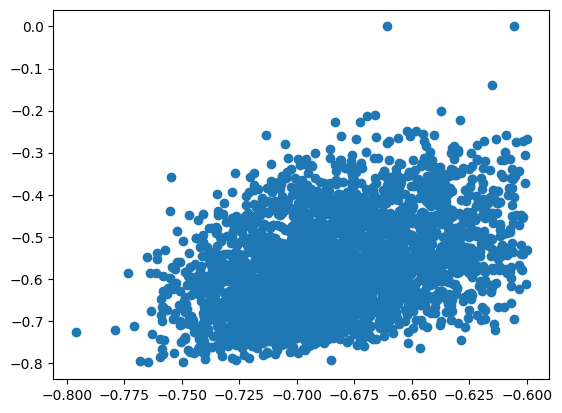

In [17]:
plt.scatter(meta2.pet_correlation, meta2.mri_correlation)

In [20]:
meta2.pet_correlation.max()

-0.6000677943229675

In [21]:
meta2.mri_correlation.max()

-1.7601477111384156e-06

In [56]:
certain_meta2 = meta2[abs(meta2['mri_correlation'])>= 0.6]
certain_meta2.reset_index(drop=True, inplace = True)

In [23]:
certain_meta2

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,Description,...,mri_95q,mri_99q,mri_999q,PATH_registered,pet_MI,pet_correlation,pet_MSE,mri_MI,mri_correlation,mri_MSE
0,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,1/01/2016,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),...,400.404616,561.022889,715.850910,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.742589,-0.700001,4016528.00,-0.590040,-0.602801,13465546.0
1,A4,NaN,M,71.4,amyloidE,SCV2,1/01/2016,82.5,PET,Florbetapir <- PET Scan,...,1346.653394,1690.529869,2097.628151,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.682154,-0.693836,5177621.50,-0.678181,-0.694905,10675332.0
2,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2016,71.8,PET,Florbetapir <- PET Scan,...,385.074081,572.254060,664.659743,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.662772,-0.671760,3836678.75,-0.662033,-0.660721,13411558.0
3,A4,NaN,F,66.0,amyloidE,SCV2,1/01/2017,69.7,PET,Florbetapir <- None Provided,...,379.417999,439.777052,514.193627,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.681034,-0.707592,3263200.25,-0.651689,-0.734494,13491765.0
4,A4,NaN,M,89.6,LEARN amyloidNE,SCV2,1/01/2016,69.8,PET,Florbetapir <- [BR-DY_CTAC] AV45 Brain Dynamic,...,255.063329,342.645205,431.558453,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.749092,-0.758666,2455436.25,-0.654004,-0.700487,13838229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2015,73.1,PET,Florbetapir <- PET Scan,...,322.387434,430.798283,512.920024,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.636331,-0.684301,4012974.00,-0.648038,-0.698056,13643501.0
1378,ADNI,ADNI GO,M,65.3,CN,m48,12/15/2010,89.3,PET,"AV45 Co-registered, Averaged <- 20 min 3D AV45...",...,1252.057654,2077.359536,2712.287479,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.652140,-0.690018,14693802.00,-0.581678,-0.621626,10640308.0
1379,ADNI,ADNI 2,M,72.1,AD,v21,9/20/2013,81.5,PET,"AV45 Co-registered, Averaged <- Adni AV45 4 X ...",...,1169.376953,1870.213466,2206.189639,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.630204,-0.672692,14693801.00,-0.703895,-0.747532,10648284.0
1380,ADNI,ADNI 2,M,57.5,CN,v31,9/17/2014,79.1,PET,"AV45 Co-registered, Averaged <- ADNIGO - AV45 ...",...,318.847514,457.731591,631.311213,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.691691,-0.697134,2678220.00,-0.568123,-0.657128,13571198.0


In [50]:
certain_meta2.to_csv('metafile_ADDLpipeline_abeta_mri_27_05_2025_afterQC.csv', index=False)

In [79]:
unsertain_meta2 = meta2[abs(meta2['mri_correlation'])> 0.3]
#unsertain_meta2 = unsertain_meta2[abs(unsertain_meta2['correlation'])< 0.6]
unsertain_meta2.reset_index(drop=True, inplace = True)

In [80]:
unsertain_meta2

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,Description,...,mri_95q,mri_99q,mri_999q,PATH_registered,pet_MI,pet_correlation,pet_MSE,mri_MI,mri_correlation,mri_MSE
0,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,1/01/2016,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),...,400.404616,561.022889,715.850910,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.742589,-0.700001,4016528.00,-0.590040,-0.602801,13465546.0
1,ADNI,ADNI 2,M,84.9,LMCI,v21,9/30/2013,69.7,PET,"AV45 Co-registered, Averaged <- PET Brain AV_4...",...,355.890277,548.642743,712.191625,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.572765,-0.645230,4504315.00,-0.554104,-0.532243,13599320.0
2,ADNI,ADNI 2,M,75.7,CN,v21,1/22/2014,79.2,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",...,331.720949,514.238646,689.266167,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.578437,-0.605858,14693803.00,-0.563853,-0.536456,13678312.0
3,A4,NaN,M,71.4,amyloidE,SCV2,1/01/2016,82.5,PET,Florbetapir <- PET Scan,...,1346.653394,1690.529869,2097.628151,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.682154,-0.693836,5177621.50,-0.678181,-0.694905,10675332.0
4,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2016,71.8,PET,Florbetapir <- PET Scan,...,385.074081,572.254060,664.659743,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.662772,-0.671760,3836678.75,-0.662033,-0.660721,13411558.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3065,ADNI,ADNI 2,F,76.7,CN,v31,1/07/2015,78.9,PET,"AV45 Co-registered, Averaged <- AV45_Dyn_4x5mi...",...,457.167799,570.447152,660.795371,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.606811,-0.616231,3531582.50,-0.540621,-0.341432,13665184.0
3066,ADNI,ADNI GO,M,65.3,CN,m48,12/15/2010,89.3,PET,"AV45 Co-registered, Averaged <- 20 min 3D AV45...",...,1252.057654,2077.359536,2712.287479,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.652140,-0.690018,14693802.00,-0.581678,-0.621626,10640308.0
3067,ADNI,ADNI 2,M,72.1,AD,v21,9/20/2013,81.5,PET,"AV45 Co-registered, Averaged <- Adni AV45 4 X ...",...,1169.376953,1870.213466,2206.189639,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.630204,-0.672692,14693801.00,-0.703895,-0.747532,10648284.0
3068,ADNI,ADNI 2,M,57.5,CN,v31,9/17/2014,79.1,PET,"AV45 Co-registered, Averaged <- ADNIGO - AV45 ...",...,318.847514,457.731591,631.311213,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,-0.691691,-0.697134,2678220.00,-0.568123,-0.657128,13571198.0


(array([3.400e+01, 5.820e+02, 1.462e+03, 1.002e+03, 3.600e+02, 1.020e+02,
        4.200e+01, 1.100e+01, 1.600e+01, 1.000e+01, 8.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 2.000e+00]),
 array([-7.96031356e-01, -7.56257156e-01, -7.16482957e-01, -6.76708758e-01,
        -6.36934558e-01, -5.97160359e-01, -5.57386159e-01, -5.17611960e-01,
        -4.77837761e-01, -4.38063561e-01, -3.98289362e-01, -3.58515162e-01,
        -3.18740963e-01, -2.78966764e-01, -2.39192564e-01, -1.99418365e-01,
        -1.59644165e-01, -1.19869966e-01, -8.00957665e-02, -4.03215671e-02,
        -5.47367672e-04]),
 <BarContainer object of 20 artists>)

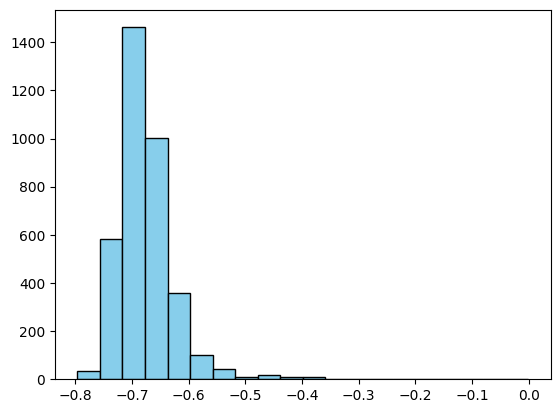

In [40]:
plt.hist(meta2['correlation'], bins=20, color='skyblue', edgecolor='black')

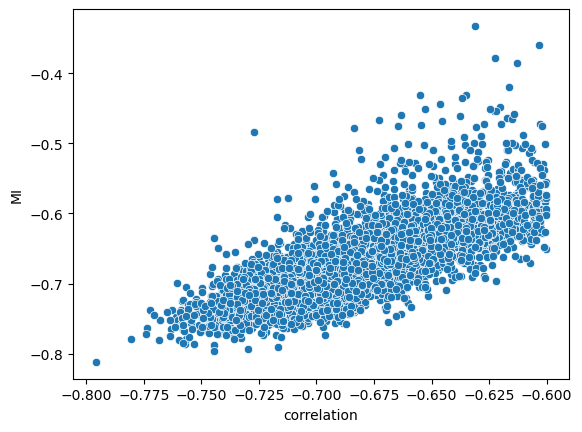

In [40]:
ax = sns.scatterplot(x="correlation", y="MI", data=certain_meta2)

In [57]:
pet = ants.image_read(certain_meta2['PATH_registered'][0])
mri = ants.image_read(certain_meta2['MRI_PATH_registered'][0])
pet = pet.numpy()
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')
mni_t1 = mni_t1.numpy()

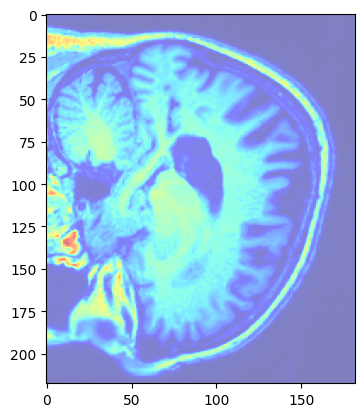

In [26]:
plt.imshow(mri[70, :, :].copy(), cmap = 'jet',alpha = 0.5) 

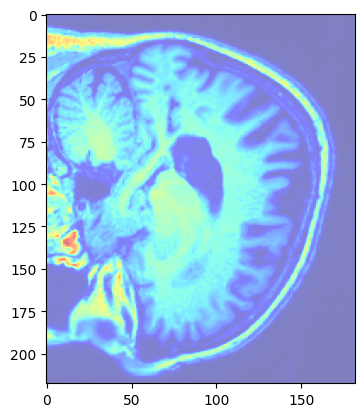

In [58]:
plt.imshow(mri[70, :, :].copy(), cmap = 'jet',alpha = 0.5) 

(-0.5, 217.5, 181.5, -0.5)

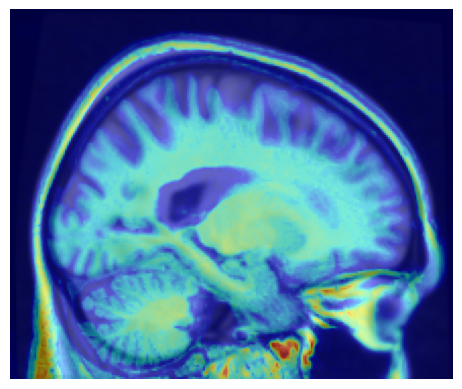

In [59]:
plt.imshow(np.rot90(mni_t1[70, :, :].copy()), cmap = 'gray')
plt.imshow(np.rot90(mri[70, :, :].copy()), cmap = 'jet',alpha = 0.5) 
plt.axis('off')

In [45]:
pet = ants.image_read(unsertain_meta2['PATH'][2])
plt.imshow(np.rot90(pet[100, :, :].copy()), cmap = 'jet') 
plt.axis('off')

AttributeError: 'ANTsImage' object has no attribute 'copy'

In [27]:
pet.shape

(128, 128, 90, 4)

In [75]:
pet = ants.image_read(unsertain_meta2['PATH_registered'][0])
mri = ants.image_read(unsertain_meta2['MRI_PATH_registered'][0])
pet = pet.numpy()
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')
mni_t1 = mni_t1.numpy()

(-0.5, 217.5, 181.5, -0.5)

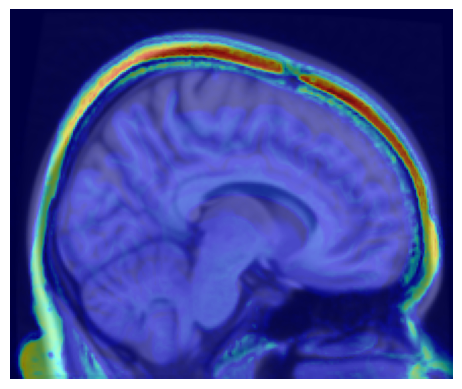

In [78]:
plt.imshow(np.rot90(mni_t1[100, :, :].copy()), cmap = 'gray')
plt.imshow(np.rot90(mri[100, :, :].copy()), cmap = 'jet',alpha = 0.5) 
plt.axis('off')

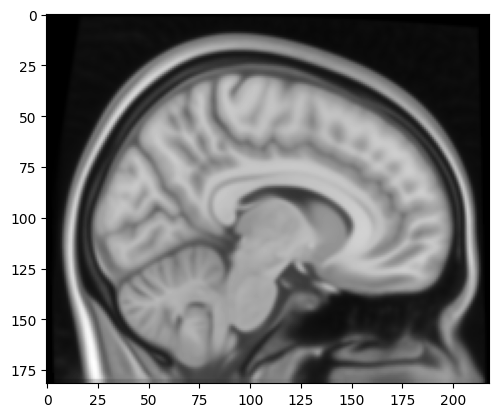

In [77]:
plt.imshow(np.rot90(mni_t1[100, :, :].copy()), cmap = 'gray')

In [38]:
mri.shape

(182, 218, 182)